# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**
**Name : Tanuja Prasad**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [67]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

# ✅Task 1 : Replace corpus with your own paragraph

The corpus given in notebook was replaced with paragraph of story book


In [68]:
corpus = '''
The camel and the fox were very good friends and very good thieves.
One day, the two friends decided to cross the river so that they could travel to a nearby farm to steal food.
The small fox could not swim so the camel said to his friend, ‘Climb up onto my back and I will swim across the river.’
And so the fox climbed up onto the camel’s back and the strong camel swam across the river to the other side.
When they had crossed the river, the camel and the fox made their way to the farm. When they finally arrived at the farm,
the fox caught herself a chicken while the camel dug up some lovely fresh vegetables.he greedy fox quickly gobbled down her chicken and then
said to her friend the camel, ‘When I finish eating I am accustomed to singing.’‘Do not sing just yet,’ said the camel as he was chewing on his dinner of vegetables.
‘I have not yet finished eating and if you sing then the farmer will hear you. Let me first finish my dinner and then you can sing as we make our way back home.’
But the fox did not pay any attention to her friend and began to sing at the top of her voice. The farmer soon heard this singing and came running out of his house waving a large stick.
‘I will teach you to steal from me!’ exclaimed the angry farmer.Because the fox was so small and nimble, she was able to run away from the farmer. But the poor camel was very slow,
and still in the middle of eating his dinner, and so he did not see the farmer until it was too late.The angry famer set upon the camel with his large stick and the poor camel received many blows to his legs and back before he was finally able to escape.
When the camel reached the river, his bones ached and he was very upset with his friend the fox.‘Why did you sing when you knew that farmer would hear you and you could see that I was still eating my dinner?’ asked the camel.
'''
print(corpus)


The camel and the fox were very good friends and very good thieves. 
One day, the two friends decided to cross the river so that they could travel to a nearby farm to steal food. 
The small fox could not swim so the camel said to his friend, ‘Climb up onto my back and I will swim across the river.’
And so the fox climbed up onto the camel’s back and the strong camel swam across the river to the other side.
When they had crossed the river, the camel and the fox made their way to the farm. When they finally arrived at the farm, 
the fox caught herself a chicken while the camel dug up some lovely fresh vegetables.he greedy fox quickly gobbled down her chicken and then 
said to her friend the camel, ‘When I finish eating I am accustomed to singing.’‘Do not sing just yet,’ said the camel as he was chewing on his dinner of vegetables.
‘I have not yet finished eating and if you sing then the farmer will hear you. Let me first finish my dinner and then you can sing as we make our way back hom

# Corpus Statistics (Additional)
Analyzed the text corpus by computing basic statistics such as total words,
unique words, total characters, and vocabulary size before training the models.

In [81]:
words = corpus.split()

print("Total Words:", len(words))
print("Unique Words:", len(set(words)))
print("Total Characters:", len(corpus))
print("Vocabulary Size:", total_words)

Total Words: 363
Unique Words: 176
Total Characters: 1853
Vocabulary Size: 160


# Top 15 Most Frequent Words (Additional)

This visualization shows the 15 most frequently occurring words in the text corpus, helping identify common terms and understand the overall word distribution before training the models.

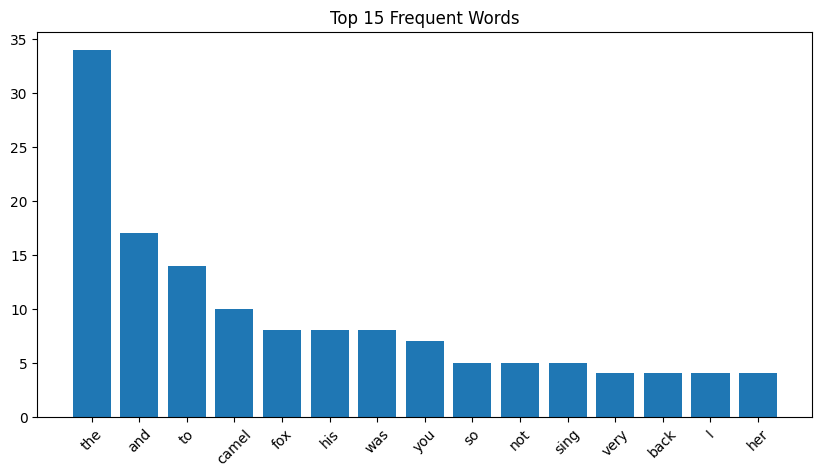

In [70]:
from collections import Counter

word_freq = Counter(words)

common = word_freq.most_common(15)

labels = [x[0] for x in common]
counts = [x[1] for x in common]

plt.figure(figsize=(10,5))
plt.bar(labels, counts)
plt.xticks(rotation=45)
plt.title("Top 15 Frequent Words")
plt.show()

# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [71]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 160
X shape: (361, 51)
y shape: (361,)


## ✅Task 2: Increase embedding dimension
Created emb_dim variable and assigned 64
## ✅Task 3 :Increase epochs to 200
Created epoch variable and assigned epochs to 200
## ✅Task 4 : Change hidden units 64 → 128
Created hidden_units variable and assigned 128

In [72]:
emb_dim=64
epoch=200
hidden_units=128

# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [66]:
rnn_model = Sequential([
    Embedding(total_words, emb_dim, input_length=max_len-1),
    SimpleRNN(hidden_units),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])


import time
start = time.time()
rnn_history = rnn_model.fit(X, y, epochs=epoch, verbose=0)
rnn_end=time.time()-start
print("Vanilla RNN training completed")
print(f"Vanilla RNN training completed in {rnn_end:.1f}s")



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed
Vanilla RNN training completed in 67.05s


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [73]:
lstm_model = Sequential([
    Embedding(total_words, emb_dim, input_length=max_len-1),
    LSTM(hidden_units),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])



start = time.time()
lstm_history = lstm_model.fit(X, y, epochs=epoch, verbose=0)
lstm_end=time.time()-start
print("LSTM training completed")
print(f"Vanilla RNN training completed in {lstm_end:.1f}s")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


LSTM training completed
Vanilla RNN training completed in 221.2s


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [74]:
gru_model = Sequential([
    Embedding(total_words, emb_dim, input_length=max_len-1),
    GRU(hidden_units),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

start = time.time()
gru_history = gru_model.fit(X, y, epochs=epoch, verbose=0)
gru_end=time.time()-start
print("GRU training completed")
print(f"Vanilla RNN training completed in {gru_end:.1f}s")

GRU training completed
Vanilla RNN training completed in 202.03s


## 📉 Compare Training Loss

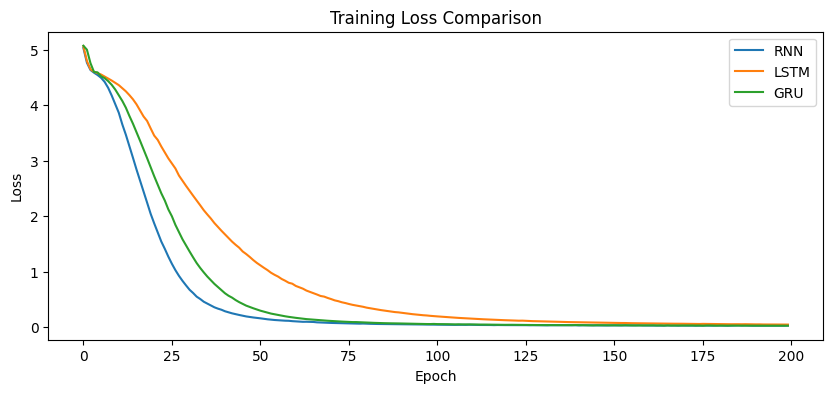

In [76]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

## Compare Training Accuracy (Additional)

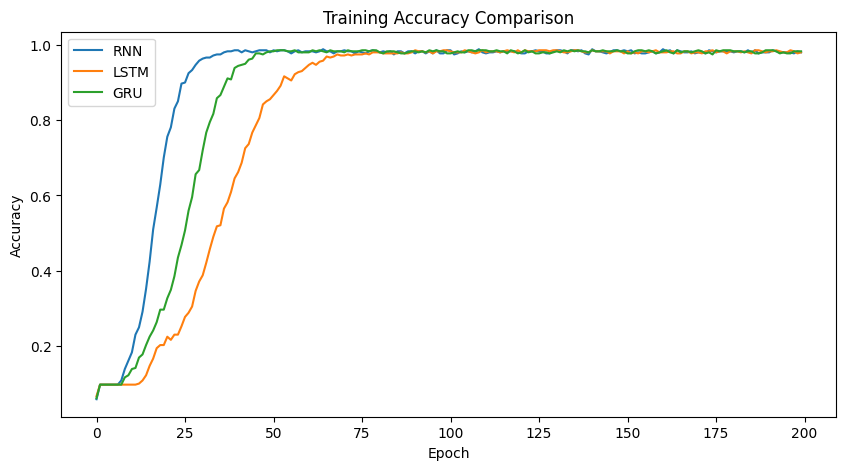

In [77]:
plt.figure(figsize=(10,5))

plt.plot(rnn_history.history['accuracy'],label='RNN')
plt.plot(lstm_history.history['accuracy'],label='LSTM')
plt.plot(gru_history.history['accuracy'],label='GRU')

plt.legend()
plt.title("Training Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

# Model Performance Comparison (Additional)

In [78]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Vanilla RNN", "LSTM", "GRU"],
    "Params": [rnn_model.count_params(), lstm_model.count_params(), gru_model.count_params()],
    "Final Loss": [rnn_history.history['loss'][-1], lstm_history.history['loss'][-1], gru_history.history['loss'][-1]],
    "Final Accuracy": [rnn_history.history['accuracy'][-1], lstm_history.history['accuracy'][-1], gru_history.history['accuracy'][-1]],
    "Training Time (s)": [rnn_end, lstm_end, gru_end]
})
comparison

,Model,Params,Final Loss,Final Accuracy,Training Time (s)
0,Vanilla RNN,55584,0.032226,0.980609,67.054902
1,LSTM,129696,0.049084,0.980609,221.150364
2,GRU,105376,0.029161,0.983379,202.025519


# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [79]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

# ✅ Task 5 Generate 10 words instead of 5


In [80]:
print("RNN :", generate_text(rnn_model, "The camel", 10))
print("LSTM:", generate_text(lstm_model, "The camel", 10))
print("GRU :", generate_text(gru_model, "The camel", 10))

RNN : The camel and the fox were very good friends and very good
LSTM: The camel and the fox were very good friends and very good
GRU : The camel and the fox were very good friends and very good


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. ✅Replace corpus with your own paragraph
2. ✅Increase embedding dimension
3. ✅Increase epochs to 200
4. ✅Change hidden units 64 → 128
5. ✅Generate 10 words instead of 5



# ✅Additional Analysis

1.   ✅ Added Corpus Statistics
2.   ✅ Performed Word Frequency Analysis
3.   ✅ Measured Model Training Time
4.   ✅ Compared Training Accuracy
5.   ✅ Created Final Performance Comparison Table






# ✅Learning Outcomes
Understood how text is converted into numerical sequences using tokenization.
Learned the working of Vanilla RNN, LSTM, and GRU for text generation.
Compared the models based on training loss, accuracy, parameters, and training time.
Explored basic text analysis using corpus statistics and word frequency visualization.
Gained practical experience in sequence modeling and next-word prediction using TensorFlow.

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**